In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import wandb
from dotenv import load_dotenv
from IPython.display import display

sys.path.append(os.path.abspath("../.."))

import src.utils.hill_climbing as hc

In [2]:
# Load data
load_dotenv(dotenv_path="../../.env")
data_id: str = "034"
level: str = "l2"

feature_dir = Path(f"../../artifacts/features/{data_id}")
with open(feature_dir / "meta.json", "r") as f:
    meta = json.load(f)

train_paths = meta["train_paths"]
test_paths = meta["test_paths"]

run_id = Path(f"hc-{data_id}")
run_dir = "../../runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Hill Climbing
result = hc.hill_climbing_auc(
    train_paths,
    test_paths
)

0 We begin with best single model AUC 0.97599 from xgb-023-trl44-s42
New best score: 0.97651
adding: xgb-026-trl21-s42
with weight: 0.480

New best score: 0.97656
adding: xgb-023-trl58-s42
with weight: 0.220

New best score: 0.97659
adding: xgb-026-trl19-s42
with weight: 0.120

New best score: 0.97660
adding: xgb-027-trl17-s42
with weight: 0.090

New best score: 0.97661
adding: xgb-030-trl20-s42
with weight: 0.100

=> We reached tolerance 1e-05


,model,weight
0,xgb-023-trl44-s42,0.292324
1,xgb-026-trl21-s42,0.269838
2,xgb-023-trl58-s42,0.158558
3,xgb-030-trl20-s42,0.100000
4,xgb-026-trl19-s42,0.098280
5,xgb-027-trl17-s42,0.081000


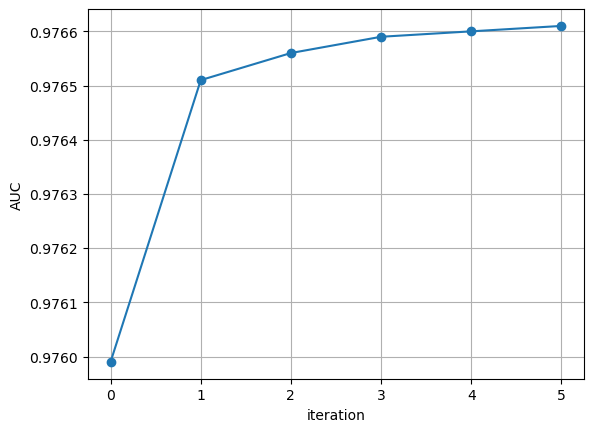

In [4]:
# 結果の可視化
ax = result["history_df"].plot(x="iteration", y="score", marker="o", legend=False)
ax.set_ylabel("AUC")
ax.grid(True)
ax.figure.savefig(run_dir / "progression.png", dpi=300, bbox_inches="tight")

# 重みトップを見る
wdf = pd.DataFrame(list(result["weights"].items()), columns=["model", "weight"])\
        .sort_values("weight", ascending=False).reset_index(drop=True)
display(wdf.head(20))

In [5]:
# === WANDB ===
wandb_project = os.environ.get("COMPETITION_NAME")
wandb.login(key=os.environ.get("WANDB_API_KEY"))

run = wandb.init(
    project=wandb_project,
    group=f"hc-{data_id}",
    name=data_id,
    job_type="cv_training",
    tags=["hc", level],
    config={
        "data_id": data_id
    },
    dir="../../artifacts"
)
run.summary["weights"] = result["weights"]   # dictをそのまま
run.summary["auc_oof"] = float(result["history_df"]["score"].max())
wandb.log({"progression": wandb.Image(run_dir / "progression.png")})
run.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/hanse/.netrc
wandb: Currently logged in as: kaitookano (kaitookano-waseda-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


auc_oof,0.97661


In [7]:
# save oof pred and test pred
manifest = {
    "run_id": str(run_id),
    "wandb_id": run.id,
    "wandb_url": run.url,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": "hc",
    "data_id": data_id,
    "feature_dir": str(feature_dir.resolve()),
    "run_dir": str(run_dir.resolve()),
    "cv_score": float(result["history_df"]["score"].max()),
    "weights": result["weights"],
    "submission": {
        "competition": None,
        "ref": None,
        "file": None,
        "public_score": None,
        "private_score": None,
        "submitted_at": None
    }
}

with open(run_dir / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=4)

print("manifest saved", run_dir / "manifest.json")

# oof and test pred
np.save(run_dir / "oof.npy", result["oof_pred"])
np.save(run_dir / "test.npy", result["test_pred"])

print(f"oof and test preds saved successfully in:\n{run_dir}")

manifest saved ../../runs/hc-034/manifest.json
oof and test preds saved successfully in:
../../runs/hc-034
